# HoeffdingTree Missing-Value Policies

This tutorial shows what `missing_value_policy` changes at prediction time.

The three options are:

- `default`: use MOA's original prediction behavior
- `random`: when a split feature is missing, follow one randomly chosen child
- `all`: when a split feature is missing, follow all available children and sum their votes

The tree plot renders the full learned tree. Highlighted nodes and edges show the traced prediction path, and any internal node that supplies fallback votes is labeled with `fallback votes`.

---

*More information about CapyMOA can be found at* https://www.capymoa.org.

**last update on 24/04/2026**



## Imports

In [ ]:
import numpy as np
import pandas as pd

from IPython.display import Markdown, display

from capymoa.classifier import HoeffdingTree
from capymoa.datasets import Electricity
from capymoa.instance import Instance

try:
    from graphviz import Source

    GRAPHVIZ_AVAILABLE = True
except Exception:
    GRAPHVIZ_AVAILABLE = False
    Source = None

## Helper Functions

In [ ]:
def show_dot(dot):
    if GRAPHVIZ_AVAILABLE:
        display(Source(dot))
    else:
        display(
            Markdown("Graphviz is not available, so the DOT source is shown below.")
        )
        display(Markdown("```dot\n" + dot + "\n```"))


def root_split_feature_index(model):
    root = model.get_tree_root()
    if root is None or root.isLeaf():
        return 0

    split_test = root.getSplitTest()
    try:
        depends_on = list(split_test.getAttsTestDependsOn())
        if depends_on:
            return int(depends_on[0])
    except Exception:
        return 0

    return 0


def make_missing_instance(schema, base_instance, missing_index):
    x = np.asarray(base_instance.x, dtype=float).copy()
    x[missing_index] = np.nan

    instance = Instance.from_array(schema, x)
    instance.java_instance.getData().setMissing(int(missing_index))
    return instance


def train_model(policy, schema, training_instances=1000, seed=49):
    stream = Electricity()
    model = HoeffdingTree(
        schema=schema,
        random_seed=seed,
        missing_value_policy=policy,
    )

    for i, instance in enumerate(stream):
        if i >= training_instances:
            break
        model.train(instance)

    return model

## Train The Models

All three models see the same stream. The only difference is how they handle missing values during prediction.


In [ ]:
stream = Electricity()
schema = stream.get_schema()
base_instance = stream.next_instance()

policies = ["default", "random", "all"]
models = {policy: train_model(policy, schema) for policy in policies}

print("trained policies:", policies)

trained policies: ['default', 'random', 'all']


## Create One Missing-Value Example

We take one real instance and mark the root split feature as missing. If the tree has not split yet, the first feature is used.


In [ ]:
missing_index = root_split_feature_index(models["default"])
example = make_missing_instance(schema, base_instance, missing_index)

print("Missing feature index:", missing_index)
print("x:", example.x)
print(
    "Java missing flag:", example.java_instance.getData().isMissing(int(missing_index))
)

Missing feature index: 3
x: [0.       1.       0.            nan 0.439155 0.003467 0.422915 0.414912]
Java missing flag: True


## Compare Predictions

In [ ]:
rows = []
for policy, model in models.items():
    proba = model.predict_proba(example)
    prediction = int(np.argmax(proba)) if proba is not None else None

    rows.append(
        {
            "policy": policy,
            "prediction": prediction,
            "probabilities": None if proba is None else np.round(proba, 4).tolist(),
        }
    )

pd.DataFrame(rows)

,policy,prediction,probabilities
0,default,1,"[0.455, 0.545]"
1,random,1,"[0.0, 1.0]"
2,all,1,"[0.0, 1.0]"


## Plot The Tree

The highlighted path shows how each policy routes the same missing-value example through the learned tree. The full tree is rendered; highlighting only marks the path used for prediction. The `all` policy can highlight multiple branches. If a split node supplies fallback votes, the node label shows `fallback votes`.



### Policy: `default`

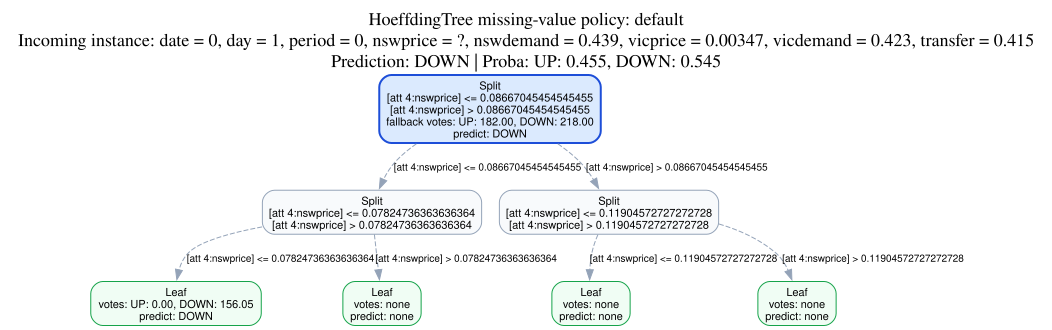

### Policy: `random`

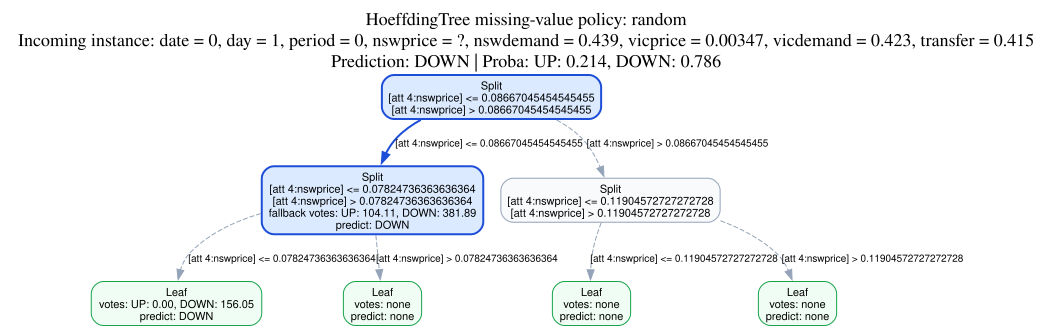

### Policy: `all`

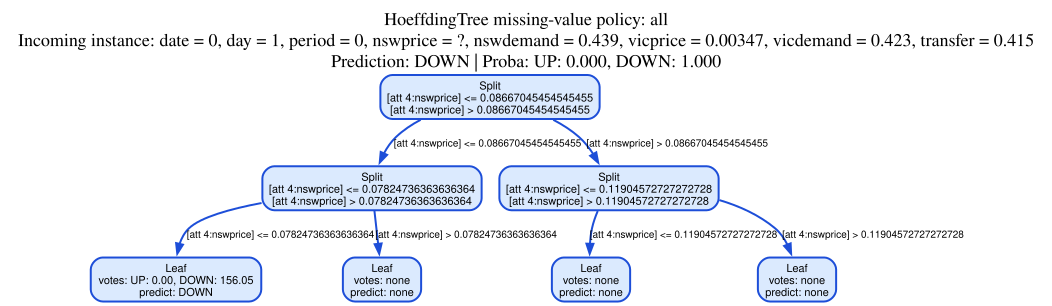

In [ ]:
for policy in policies:
    display(Markdown(f"### Policy: `{policy}`"))
    dot = models[policy].export_tree_to_dot(
        sample_instance=example,
        title=f"HoeffdingTree missing-value policy: {policy}",
        include_leaf_votes=True,
        highlight_path=True,
    )
    show_dot(dot)